# Apple inc. (AAPL) Historical Stock Market Analysis Using Python
## Week 6 Internship Project - Advanced Python Analysis
**Intern:** Danjuma Zainab
**Organization:** AnalystLab Africa
**Internship Duration:** Batch B (1st June- 1st August 2026)

----

### Project Overview
This Project analyzes the historical stock market performance of Apple Inc. (AAPL) using Python. The analysis focuses on data transformation with Pandas, time-series analysis, feature engineering, and data visualization to identify trends, patterns, and insights from historical stock market data. The datset was obtained from Yahoo Finance using the **yfinance** Python library

## AAPL install yfinance

In [123]:
!pip install yfinance

# 1. Importing Required Libraries

In [124]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

# 2.  Downloading and Loading the Dataset

In [169]:


df = yf.download("AAPL", period="5y", auto_adjust=False)

[*********************100%***********************]  1 of 1 completed


In [170]:
df = df.reset_index()

In [164]:
df.head()

,level_0,index,Date,Adj Close,Close,High,Low,Open,Volume
0,0,5,2021-08-12,145.348267,148.889999,149.050003,145.839996,146.190002,72282600
1,1,6,2021-08-13,145.553268,149.100006,149.440002,148.270004,148.970001,59375000
2,2,7,2021-08-16,147.525208,151.119995,151.190002,146.470001,148.539993,103296000
3,3,8,2021-08-17,146.617325,150.190002,151.679993,149.089996,150.229996,92229700
4,4,9,2021-08-18,142.878433,146.360001,150.720001,146.149994,149.800003,86326000


In [136]:
df.to_csv("AAPL_Historical_Data.csv", index=False)

In [171]:
import os
print(os.listdir())

['.ipynb_checkpoints', 'AAPL_Historical_Data.csv', 'AAPL_Stock_Analysis.ipynb']


In [172]:
df=pd.read_csv("AAPL_Historical_Data.csv")

# 3. Previewing the Dataset
Before performing any analysis, it is important to inspect the first few rows of the dataset to undertand its structure and verify that it has loaded correctly.

In [139]:
df.head(10)

,index,Date,Adj Close,Close,High,Low,Open,Volume
0,0,NaN,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL
1,1,2021-08-06,142.66366577148438,146.13999938964844,147.11000061035156,145.6300048828125,146.35000610351562,54126800
2,2,2021-08-09,142.6148681640625,146.08999633789062,146.6999969482422,145.52000427246094,146.1999969482422,48908700
3,3,2021-08-10,142.13650512695312,145.60000610351562,147.7100067138672,145.3000030517578,146.44000244140625,69023100
4,4,2021-08-11,142.39031982421875,145.86000061035156,146.72000122070312,145.52999877929688,146.0500030517578,48493500
5,5,2021-08-12,145.3482666015625,148.88999938964844,149.0500030517578,145.83999633789062,146.19000244140625,72282600
6,6,2021-08-13,145.5532684326172,149.10000610351562,149.44000244140625,148.27000427246094,148.97000122070312,59375000
7,7,2021-08-16,147.52520751953125,151.1199951171875,151.19000244140625,146.47000122070312,148.5399932861328,103296000
8,8,2021-08-17,146.61732482910156,150.19000244140625,151.67999267578125,149.08999633789062,150.22999572753906,92229700
9,9,2021-08-18,142.87843322753906,146.36000061035156,150.72000122070312,146.14999389648438,149.8000030517578,86326000


# 4. Understanding the Dataset Structure
In this section, we examine the dataset by checking the number of rows and columns, data types, and identify any missing values.


In [173]:
df.shape

(1254, 8)

In [174]:
print(df.head())
print(df.columns)

   index        Date           Adj Close               Close  \
0      0         NaN                AAPL                AAPL   
1      1  2021-08-06  142.66366577148438  146.13999938964844   
2      2  2021-08-09   142.6148681640625  146.08999633789062   
3      3  2021-08-10  142.13650512695312  145.60000610351562   
4      4  2021-08-11  142.39031982421875  145.86000061035156   

                 High                 Low                Open    Volume  
0                AAPL                AAPL                AAPL      AAPL  
1  147.11000061035156   145.6300048828125  146.35000610351562  54126800  
2   146.6999969482422  145.52000427246094   146.1999969482422  48908700  
3   147.7100067138672   145.3000030517578  146.44000244140625  69023100  
4  146.72000122070312  145.52999877929688   146.0500030517578  48493500  
Index(['index', 'Date', 'Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object')


#### The Dataset contains 1254 rows and 8 columns

In [175]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1254 entries, 0 to 1253
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   index      1254 non-null   int64 
 1   Date       1253 non-null   object
 2   Adj Close  1254 non-null   object
 3   Close      1254 non-null   object
 4   High       1254 non-null   object
 5   Low        1254 non-null   object
 6   Open       1254 non-null   object
 7   Volume     1254 non-null   object
dtypes: int64(1), object(7)
memory usage: 78.5+ KB


In [176]:
df.describe()

,index
count,1254.000000
mean,626.500000
std,362.142928
min,0.000000
25%,313.250000
50%,626.500000
75%,939.750000
max,1253.000000


## 5. Data Cleaning and Preprocessing

Before performing analysis, the dataset was cleaned to ensure that all columns had the correct data types and unnecessary columns were removed. This improves data quality and ensures accurate analysis.

### 5.1. Remove the first Row

In [177]:
df = df.iloc[1:].reset_index(drop=True)

### 5.2. Drop Index Column

In [179]:
df.drop(columns=["index"],inplace=True)

### 5.3. Convert the Rows to numbers

In [180]:
df["Close"] = pd.to_numeric(df["Close"])
df["High"] = pd.to_numeric(df["High"])
df["Low"] = pd.to_numeric(df["Low"])
df["Open"] = pd.to_numeric(df["Open"])
df["Volume"] = pd.to_numeric(df["Volume"])

### 5.4. Check Again

In [181]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1253 entries, 0 to 1252
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       1253 non-null   object 
 1   Adj Close  1253 non-null   object 
 2   Close      1253 non-null   float64
 3   High       1253 non-null   float64
 4   Low        1253 non-null   float64
 5   Open       1253 non-null   float64
 6   Volume     1253 non-null   int64  
dtypes: float64(4), int64(1), object(2)
memory usage: 68.7+ KB


### 5.5. Convert date to date time

In [182]:
df["Date"] = pd.to_datetime(df["Date"])

### 5.6. Convert Adjusted Close to Numeric

In [183]:
df["Adj Close"] = pd.to_numeric(df["Adj Close"])

### 5.7. Check for missing Values

In [184]:
 df.isnull().sum()

Date         0
Adj Close    0
Close        0
High         0
Low          0
Open         0
Volume       0
dtype: int64

### 5.8. Verify Changes

In [185]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1253 entries, 0 to 1252
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       1253 non-null   datetime64[ns]
 1   Adj Close  1253 non-null   float64       
 2   Close      1253 non-null   float64       
 3   High       1253 non-null   float64       
 4   Low        1253 non-null   float64       
 5   Open       1253 non-null   float64       
 6   Volume     1253 non-null   int64         
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 68.7 KB


In [186]:
df.shape

(1253, 7)

### The dataset contains 1253 rows and 7 columns after cleaning and preprocessing.

# 6. Data Transformation with Pandas

Data transformation involves modifying and creating new data to make analysis more meaningful. In this section, new features are created from the existing stock market data to support trend analysis and performance evaluation.

### 6.1. Sorting the Dataset by Date

The dataset is sorted in chronological order to ensure that all time-series calculations such as percentage changes and moving averages are computed correctly.

In [187]:
df = df.sort_values("Date")
df.head()

,Date,Adj Close,Close,High,Low,Open,Volume
0,2021-08-06,142.663666,146.139999,147.110001,145.630005,146.350006,54126800
1,2021-08-09,142.614868,146.089996,146.699997,145.520004,146.199997,48908700
2,2021-08-10,142.136505,145.600006,147.710007,145.300003,146.440002,69023100
3,2021-08-11,142.390320,145.860001,146.720001,145.529999,146.050003,48493500
4,2021-08-12,145.348267,148.889999,149.050003,145.839996,146.190002,72282600


### 6.2. Daily Price Change

A new feature called **Daily Price Change** was created by subtracting the opening price from the closing price. A positive value indicates that the stock gained value during the trading day, while a negative value indicates a loss.

In [188]:
df["Daily Price Change"] = df["Close"] - df["Open"]

df[["Date", "Open", "Close", "Daily Price Change"]].head()

,Date,Open,Close,Daily Price Change
0,2021-08-06,146.350006,146.139999,-0.210007
1,2021-08-09,146.199997,146.089996,-0.110001
2,2021-08-10,146.440002,145.600006,-0.839996
3,2021-08-11,146.050003,145.860001,-0.190002
4,2021-08-12,146.190002,148.889999,2.699997


### 6.3. Percentage Price Change

The percentage price change measures the daily percentage gain or loss relative to the opening price. This metric allows stock performance to be compared across different trading days.

In [189]:
df["Percentage Price Change"] = (
    (df["Close"] - df["Open"]) / df["Open"]
) * 100

df[["Date", "Percentage Price Change"]].head()

,Date,Percentage Price Change
0,2021-08-06,-0.143496
1,2021-08-09,-0.075240
2,2021-08-10,-0.573611
3,2021-08-11,-0.130094
4,2021-08-12,1.846909


### 6.4  Extracting Date Components

The Year and Month were extracted from the Date column to simplify monthly and yearly trend analysis.

In [190]:
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month_name()

df[["Date", "Year", "Month"]].head()

,Date,Year,Month
0,2021-08-06,2021,August
1,2021-08-09,2021,August
2,2021-08-10,2021,August
3,2021-08-11,2021,August
4,2021-08-12,2021,August


### 6.5 Create Month Column

In [191]:
df["Month Number"] = df["Date"].dt.month

### 6.6 Preview of the Transformed Dataset

The dataset now includes additional engineered features that will be used for time-series analysis and visualization.

In [192]:
df.head()

,Date,Adj Close,Close,High,Low,Open,Volume,Daily Price Change,Percentage Price Change,Year,Month,Month Number
0,2021-08-06,142.663666,146.139999,147.110001,145.630005,146.350006,54126800,-0.210007,-0.143496,2021,August,8
1,2021-08-09,142.614868,146.089996,146.699997,145.520004,146.199997,48908700,-0.110001,-0.075240,2021,August,8
2,2021-08-10,142.136505,145.600006,147.710007,145.300003,146.440002,69023100,-0.839996,-0.573611,2021,August,8
3,2021-08-11,142.390320,145.860001,146.720001,145.529999,146.050003,48493500,-0.190002,-0.130094,2021,August,8
4,2021-08-12,145.348267,148.889999,149.050003,145.839996,146.190002,72282600,2.699997,1.846909,2021,August,8


# 7. Time-Series Analysis

Time-series analysis helps identify trends, seasonal patterns, and changes in stock prices over time. In this section, we analyze Apple's stock performance using line charts and moving averages to better understand its historical behavior.

## 7.1 Closing Price Trend

This visualization shows how Apple's closing stock price changed over the five-year period. It helps identify long-term growth, declines, and overall market trends.

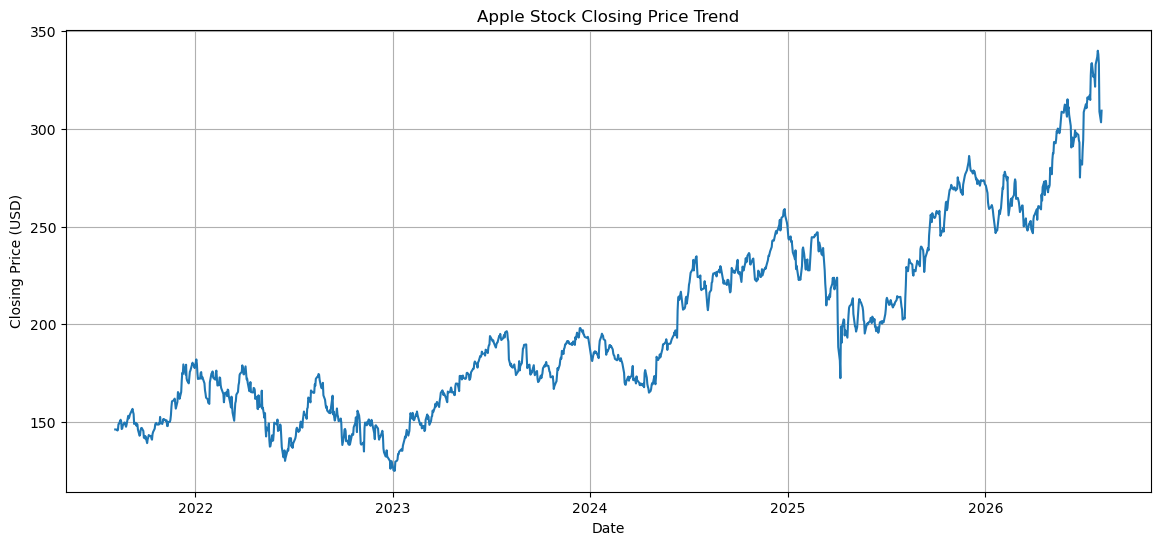

In [193]:
plt.figure(figsize=(14,6))

plt.plot(df["Date"], df["Close"])

plt.title("Apple Stock Closing Price Trend")

plt.xlabel("Date")

plt.ylabel("Closing Price (USD)")

plt.grid(True)

plt.show()

## 7.2 Trading Volume Trend

Trading volume represents the number of shares traded each day. High trading volume often indicates increased market activity and investor interest.

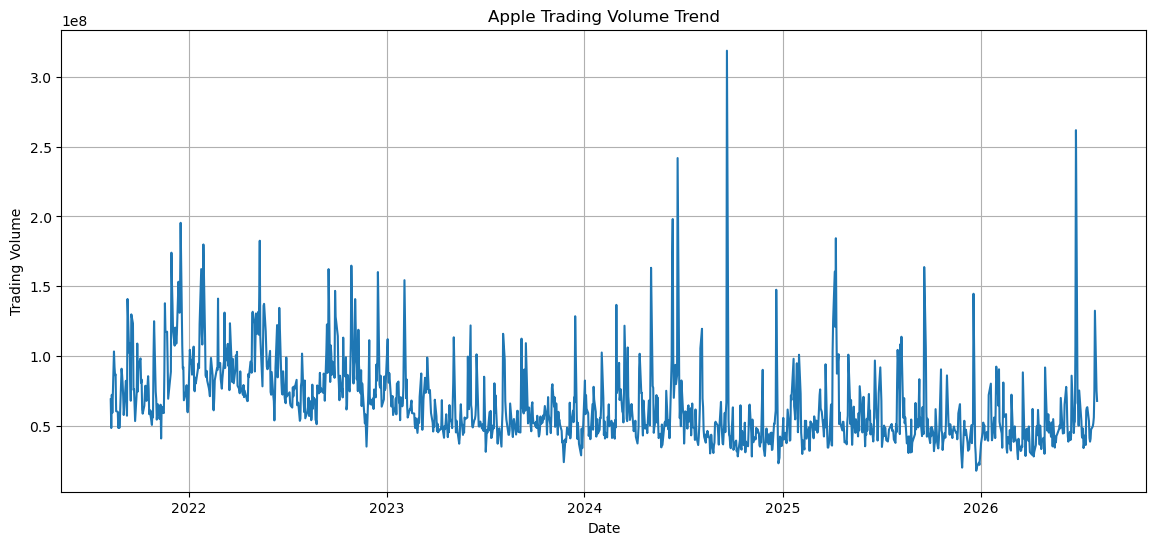

In [72]:
plt.figure(figsize=(14,6))

plt.plot(df["Date"], df["Volume"])

plt.title("Apple Trading Volume Trend")

plt.xlabel("Date")

plt.ylabel("Trading Volume")

plt.grid(True)

plt.show()

## 7.3 Seven-Day Moving Average

A 7-day moving average smooths short-term price fluctuations, making it easier to observe recent market trends.

In [194]:
df["7-Day Moving Average"] = df["Close"].rolling(window=7).mean()

df.head()

,Date,Adj Close,Close,High,Low,Open,Volume,Daily Price Change,Percentage Price Change,Year,Month,Month Number,7-Day Moving Average
0,2021-08-06,142.663666,146.139999,147.110001,145.630005,146.350006,54126800,-0.210007,-0.143496,2021,August,8,NaN
1,2021-08-09,142.614868,146.089996,146.699997,145.520004,146.199997,48908700,-0.110001,-0.075240,2021,August,8,NaN
2,2021-08-10,142.136505,145.600006,147.710007,145.300003,146.440002,69023100,-0.839996,-0.573611,2021,August,8,NaN
3,2021-08-11,142.390320,145.860001,146.720001,145.529999,146.050003,48493500,-0.190002,-0.130094,2021,August,8,NaN
4,2021-08-12,145.348267,148.889999,149.050003,145.839996,146.190002,72282600,2.699997,1.846909,2021,August,8,NaN


## 7.4 Thirty-Day Moving Average

The 30-day moving average provides a broader view of the stock's long-term trend by reducing daily price volatility.

In [195]:
df["30-Day Moving Average"] = df["Close"].rolling(window=30).mean()

df.head()

,Date,Adj Close,Close,High,Low,Open,Volume,Daily Price Change,Percentage Price Change,Year,Month,Month Number,7-Day Moving Average,30-Day Moving Average
0,2021-08-06,142.663666,146.139999,147.110001,145.630005,146.350006,54126800,-0.210007,-0.143496,2021,August,8,NaN,NaN
1,2021-08-09,142.614868,146.089996,146.699997,145.520004,146.199997,48908700,-0.110001,-0.075240,2021,August,8,NaN,NaN
2,2021-08-10,142.136505,145.600006,147.710007,145.300003,146.440002,69023100,-0.839996,-0.573611,2021,August,8,NaN,NaN
3,2021-08-11,142.390320,145.860001,146.720001,145.529999,146.050003,48493500,-0.190002,-0.130094,2021,August,8,NaN,NaN
4,2021-08-12,145.348267,148.889999,149.050003,145.839996,146.190002,72282600,2.699997,1.846909,2021,August,8,NaN,NaN


## 7.5 Closing Price vs Moving Averages

This visualization compares the daily closing price with the 7-day and 30-day moving averages to highlight short-term and long-term trends.

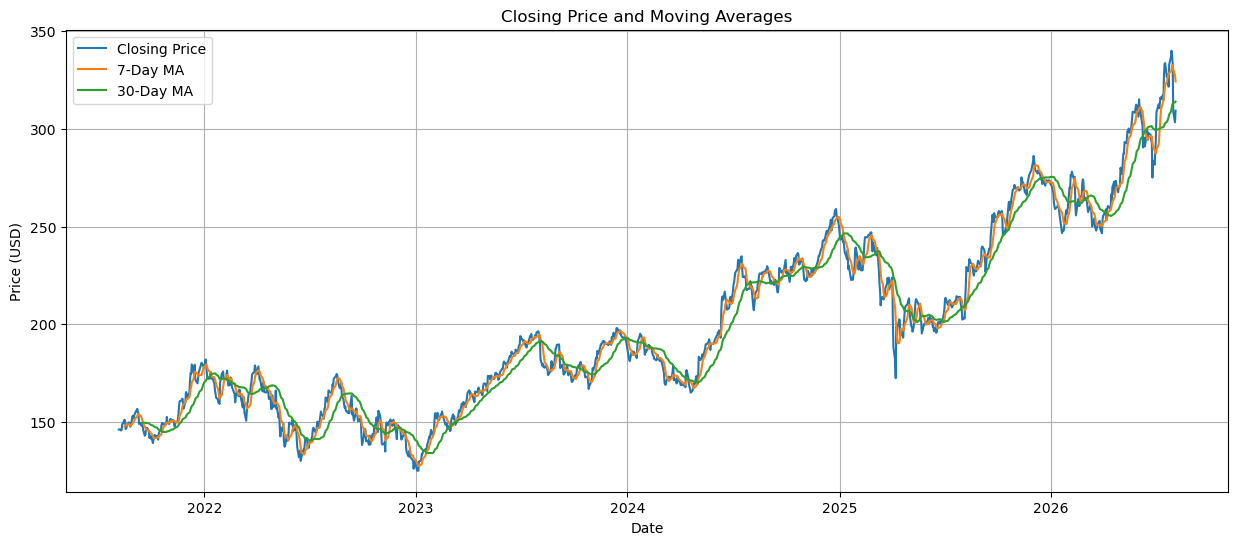

In [196]:
plt.figure(figsize=(15,6))

plt.plot(df["Date"], df["Close"], label="Closing Price")

plt.plot(df["Date"], df["7-Day Moving Average"], label="7-Day MA")

plt.plot(df["Date"], df["30-Day Moving Average"], label="30-Day MA")

plt.title("Closing Price and Moving Averages")

plt.xlabel("Date")

plt.ylabel("Price (USD)")

plt.legend()

plt.grid(True)

plt.show()

## 7.6 Daily Percentage Price Change

This chart illustrates the daily percentage gain or loss in Apple's stock price, highlighting periods of high volatility and market stability.

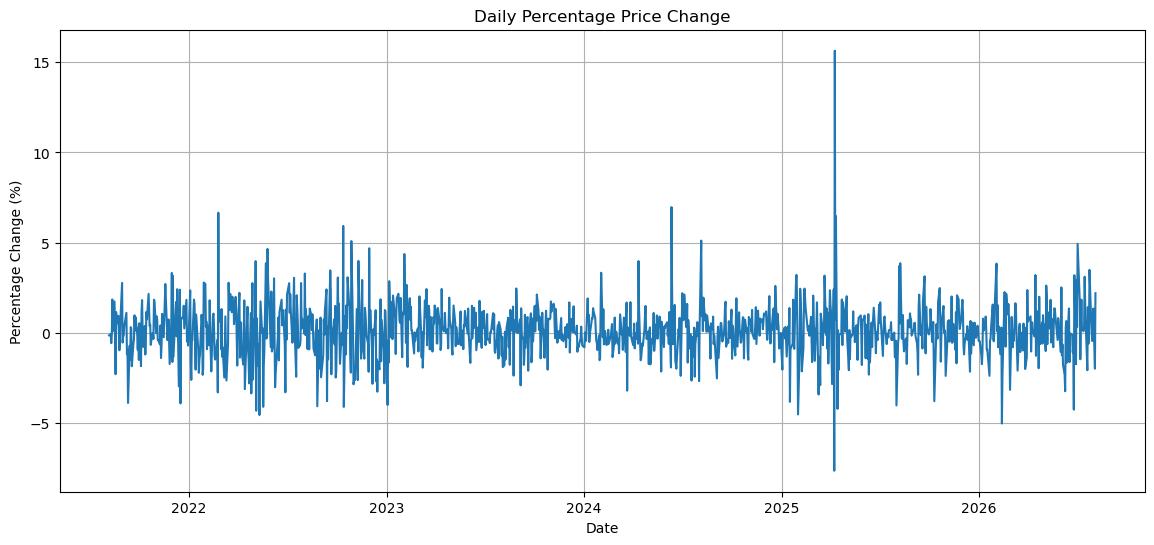

In [197]:
plt.figure(figsize=(14,6))

plt.plot(df["Date"], df["Percentage Price Change"])

plt.title("Daily Percentage Price Change")

plt.xlabel("Date")

plt.ylabel("Percentage Change (%)")

plt.grid(True)

plt.show()

# 8. Feature Engineering

Feature engineering involves creating new variables from existing data to improve analysis and generate deeper insights. In this section, additional features such as monthly returns and stock price volatility are created to better understand Apple's historical stock performance.

## 8.1 Monthly Average Returns

Monthly average percentage price changes were calculated to identify months that generally experienced stronger or weaker stock performance.

In [198]:
monthly_returns = df.groupby("Month")["Percentage Price Change"].mean().reset_index()

monthly_returns

,Month,Percentage Price Change
0,April,0.211490
1,August,0.120608
2,December,0.002570
3,February,0.239211
4,January,-0.008269
5,July,0.318160
6,June,-0.040106
7,March,0.073984
8,May,0.118160
9,November,0.283238


In [199]:
month_order = [
    "January", "February", "March", "April",
    "May", "June", "July", "August",
    "September", "October", "November", "December"
]

monthly_returns["Month"] = pd.Categorical(
    monthly_returns["Month"],
    categories=month_order,
    ordered=True
)

monthly_returns = monthly_returns.sort_values("Month")

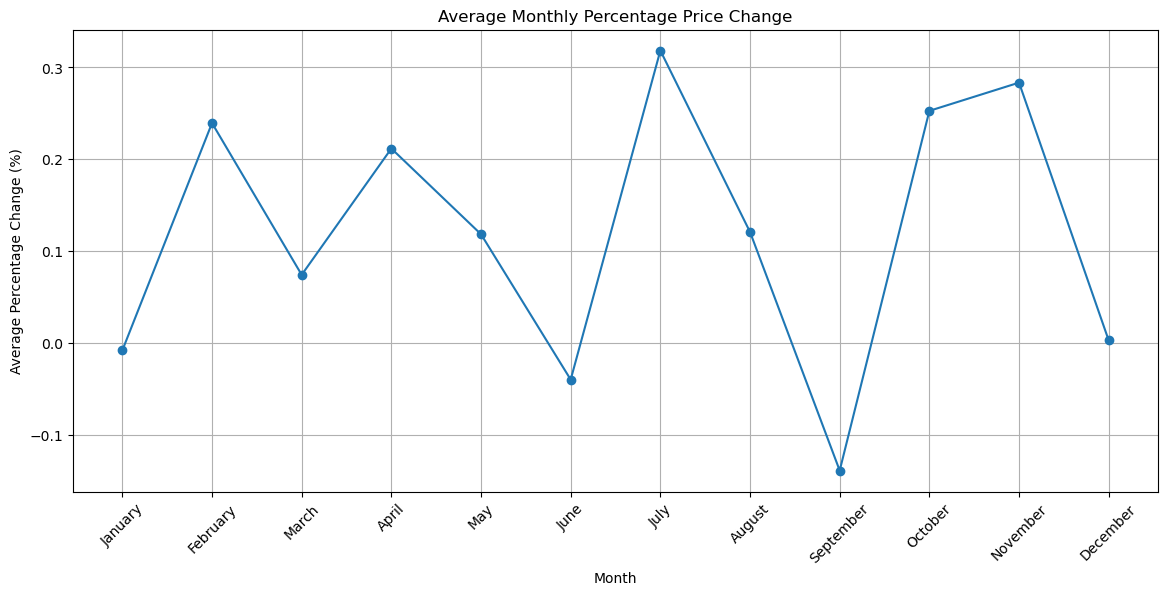

In [200]:
plt.figure(figsize=(14,6))

plt.plot(monthly_returns["Month"],
         monthly_returns["Percentage Price Change"],
         marker="o")

plt.title("Average Monthly Percentage Price Change")

plt.xlabel("Month")

plt.ylabel("Average Percentage Change (%)")

plt.xticks(rotation=45)

plt.grid(True)

plt.show()

## 8.2 Stock Price Volatility

A 30-day rolling standard deviation was calculated to measure the volatility of Apple's stock price. Higher volatility indicates greater fluctuations in stock prices.

In [201]:
df["Volatility"] = df["Percentage Price Change"].rolling(window=30).std()

df.head()

,Date,Adj Close,Close,High,Low,Open,Volume,Daily Price Change,Percentage Price Change,Year,Month,Month Number,7-Day Moving Average,30-Day Moving Average,Volatility
0,2021-08-06,142.663666,146.139999,147.110001,145.630005,146.350006,54126800,-0.210007,-0.143496,2021,August,8,NaN,NaN,NaN
1,2021-08-09,142.614868,146.089996,146.699997,145.520004,146.199997,48908700,-0.110001,-0.075240,2021,August,8,NaN,NaN,NaN
2,2021-08-10,142.136505,145.600006,147.710007,145.300003,146.440002,69023100,-0.839996,-0.573611,2021,August,8,NaN,NaN,NaN
3,2021-08-11,142.390320,145.860001,146.720001,145.529999,146.050003,48493500,-0.190002,-0.130094,2021,August,8,NaN,NaN,NaN
4,2021-08-12,145.348267,148.889999,149.050003,145.839996,146.190002,72282600,2.699997,1.846909,2021,August,8,NaN,NaN,NaN


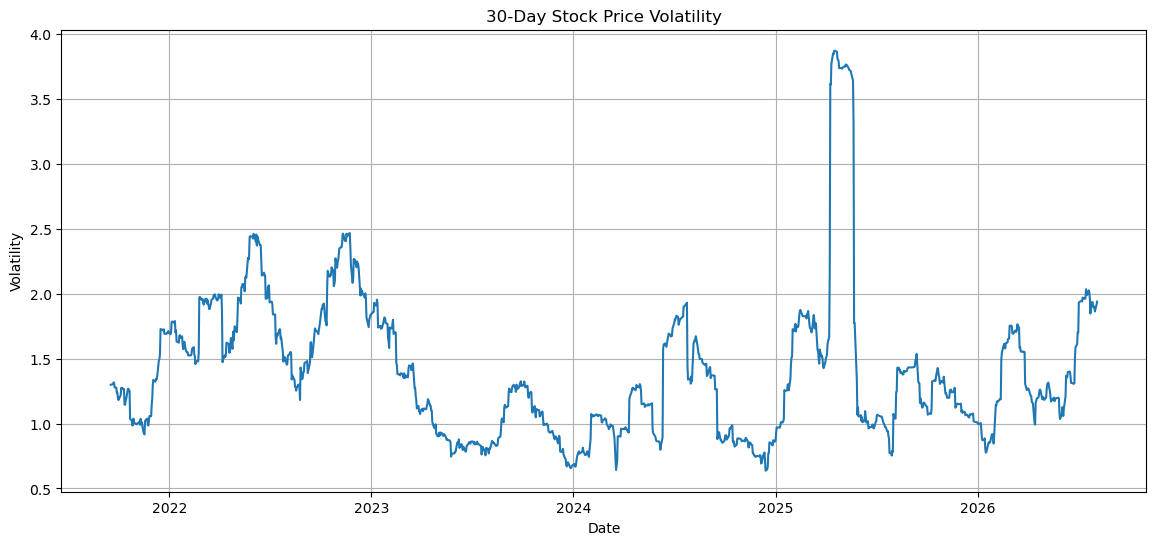

In [202]:
plt.figure(figsize=(14,6))

plt.plot(df["Date"], df["Volatility"])

plt.title("30-Day Stock Price Volatility")

plt.xlabel("Date")

plt.ylabel("Volatility")

plt.grid(True)

plt.show()

## 8.3 Highest Closing Price

The highest closing price recorded during the analysis period was identified.

In [203]:
highest_close = df.loc[df["Close"].idxmax()]

highest_close

Date                       2026-07-28 00:00:00
Adj Close                           340.079987
Close                               340.079987
High                                342.890015
Low                                 335.600006
Open                                340.029999
Volume                                51859000
Daily Price Change                    0.049988
Percentage Price Change               0.014701
Year                                      2026
Month                                     July
Month Number                                 7
7-Day Moving Average                330.269998
30-Day Moving Average                  310.462
Volatility                            1.896078
Name: 1247, dtype: object

## 8.4 Lowest Closing Price

The lowest closing price recorded during the analysis period was identified.

In [204]:
lowest_close = df.loc[df["Close"].idxmin()]

lowest_close

Date                       2023-01-05 00:00:00
Adj Close                            122.93354
Close                               125.019997
High                                127.769997
Low                                 124.760002
Open                                127.129997
Volume                                80962700
Daily Price Change                   -2.110001
Percentage Price Change              -1.659719
Year                                      2023
Month                                  January
Month Number                                 1
7-Day Moving Average                127.437141
30-Day Moving Average                  138.488
Volatility                            1.860458
Name: 356, dtype: object

## 8.5 Highest Trading Volume

The trading day with the highest trading volume was identified to determine periods of unusually high market activity.

In [205]:
highest_volume = df.loc[df["Volume"].idxmax()]

highest_volume

Date                       2024-09-20 00:00:00
Adj Close                           226.502075
Close                               228.199997
High                                233.089996
Low                                 227.619995
Open                                229.970001
Volume                               318679900
Daily Price Change                   -1.770004
Percentage Price Change              -0.769667
Year                                      2024
Month                                September
Month Number                                 9
7-Day Moving Average                222.305714
30-Day Moving Average               223.494334
Volatility                            0.933252
Name: 785, dtype: object

## 8.6 Summary Statistics

Key statistics for Apple's historical stock prices were generated to provide an overall understanding of the dataset.

In [206]:
df.describe().round(2)

,Date,Adj Close,Close,High,Low,Open,Volume,Daily Price Change,Percentage Price Change,Year,Month Number,7-Day Moving Average,30-Day Moving Average,Volatility
count,1253,1253.00,1253.00,1253.00,1253.00,1253.00,1.253000e+03,1253.00,1253.00,1253.00,1253.00,1247.00,1224.00,1224.00
mean,2024-02-02 16:11:06.560255488,197.19,199.12,201.11,196.93,198.90,6.472213e+07,0.22,0.12,2023.59,6.55,198.96,198.26,1.40
min,2021-08-06 00:00:00,122.93,125.02,127.77,124.17,126.01,1.791060e+07,-14.28,-7.65,2021.00,1.00,127.38,134.06,0.64
25%,2022-11-02 00:00:00,159.57,162.88,164.96,159.92,162.25,4.551930e+07,-1.30,-0.64,2022.00,4.00,163.19,164.34,1.00
50%,2024-02-02 00:00:00,185.52,187.87,189.30,186.06,187.70,5.637710e+07,0.21,0.10,2024.00,7.00,187.96,187.19,1.28
75%,2025-05-05 00:00:00,229.00,230.10,232.67,228.13,229.99,7.640430e+07,1.73,0.90,2025.00,10.00,230.21,229.33,1.70
max,2026-08-04 00:00:00,340.08,340.08,344.57,337.35,340.03,3.186799e+08,26.90,15.64,2026.00,12.00,332.74,314.02,3.87
std,NaN,47.46,46.56,46.93,46.11,46.47,2.858032e+07,2.94,1.50,1.50,3.44,46.08,44.19,0.56


# 9. Key Findings

Based on the analysis of Apple's historical stock market data, the following observations were made:

- Apple's stock price generally followed an upward trend over the analysis period.
- Daily stock prices experienced both gains and losses, reflecting normal market fluctuations.
- The 7-day moving average responded quickly to short-term price changes, while the 30-day moving average highlighted longer-term trends.
- Trading volume varied considerably, with periods of increased investor activity.
- Monthly average returns differed across the year, indicating that stock performance was not uniform in every month.
- The volatility analysis revealed periods of both relatively stable prices and increased market uncertainty.

# 10. Conclusion

This project demonstrated the application of Python for financial data analysis using Apple's historical stock market data. Through data cleaning, transformation, feature engineering, time-series analysis, and visualization, valuable insights into stock price movements and trading activity were obtained.

The project highlights the usefulness of Python, Pandas, and Matplotlib in analyzing time-series datasets and supports data-driven decision-making in financial analytics.